# Appliance Classification with Energy-TSPulse

This notebook demonstrates how to fine-tune **Energy-TSPulse** for **appliance-level classification** using building energy meter data.

We treat appliance states (e.g., cooling, heating, refrigeration) as supervised classification targets and adapt a pretrained Energy-TSPulse model to predict these labels from fixed-length energy consumption sequences.

---

## 🎯 Objective

Given:
- Hourly building-level energy consumption time series  
- Binary appliance activity labels (e.g., `cooling_ON`, `fans_ON`)  

We aim to:
- Split each time series into fixed `context windows of length 512`
- Use each 512-length window as an input sample for classification  
- Fine-tune Energy-TSPulse to map energy usage patterns → appliance states  
- Evaluate performance using **accuracy** and **macro F1 score**  
- Save task-specific fine-tuned classification models  


In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoConfig
from tsfm_public.models.tspulse.modeling_tspulse import TSPulseForClassification
from collections import OrderedDict
from safetensors.torch import load_file
import os
import logging
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sktime.classification.dummy import DummyClassifier
# Configure logging to show all info
logging.basicConfig(level=logging.INFO, format='INFO:%(name)s:%(message)s')
logger = logging.getLogger(__name__)


In [2]:
# ===============================
# --- Data Loading + EDA ---
# ===============================

# Load time series data
energy_df = pd.read_csv('../Dataset/Classification/comstock_60min_small.csv')

# Load label file
labels_df = pd.read_csv('../Dataset/Classification/comstock_60min_labels.csv')

print("Energy Data Shape:", energy_df.shape)
print("Labels Shape:", labels_df.shape)


# Preview first few rows
energy_df.head()



Energy Data Shape: (168, 1001)
Labels Shape: (1000, 12)


,Timestamp,73206-0,84687-0,148366-0,126539-0,23028-0,116299-0,122105-0,16125-0,111146-0,...,34613-0,12423-0,102118-0,89944-0,104408-0,54821-0,92483-0,10062-0,7656-0,64186-0
0,2018-01-01 00:00:00,12.6730,0.8147,102.6011,0.9508,9.3069,52.7706,4.0124,4.3562,12.4350,...,0.3071,3.1569,14.6270,1.3692,8.4171,48.0188,2.9906,2.8055,0.8597,1.1101
1,2018-01-01 01:00:00,13.2609,0.7156,99.9958,0.9782,12.4617,51.9490,3.3915,4.0074,12.5831,...,0.2884,3.3826,9.6584,1.3159,8.0343,47.9524,2.7670,2.6727,0.8771,1.1493
2,2018-01-01 02:00:00,14.5754,0.6363,98.7648,1.0011,15.7500,51.6240,2.3649,3.7368,12.8171,...,0.2809,3.8093,9.0529,1.3015,7.8971,52.8306,2.6159,3.4510,0.8603,1.1936
3,2018-01-01 03:00:00,11.0316,0.5799,97.5120,0.9428,8.0838,51.4701,2.0681,2.1125,12.8428,...,0.2779,1.9341,5.5975,1.3190,7.5558,49.7141,2.0853,2.3971,0.8451,1.0425
4,2018-01-01 04:00:00,9.5491,0.5569,97.5285,0.9424,4.0729,51.3066,1.7177,1.7441,12.8094,...,0.2771,1.1953,4.4880,1.3366,7.8178,46.2016,2.0980,1.6785,0.8409,1.0492


In [3]:
labels_df.head()

,cooling_ON,exterior_lighting_ON,fans_ON,heat_recovery_ON,heat_rejection_ON,heating_ON,interior_equipment_ON,interior_lighting_ON,pumps_ON,refrigeration_ON,water_systems_ON,id
0,1,1,1,0,0,1,1,1,1,0,0,73206
1,1,1,1,0,0,0,1,1,1,0,0,84687
2,1,1,1,0,1,0,1,1,1,1,1,148366
3,0,1,1,0,0,0,1,1,1,0,1,126539
4,0,1,0,0,0,1,1,1,1,0,1,23028


In [4]:

# Check missing values
missing_counts = energy_df.isna().sum().sum()
print(f"Total missing values in dataset: {missing_counts}")

# Remove timestamp column and transpose:
# rows -> individual time series
# cols -> timesteps
X_raw = energy_df.drop(columns=["Timestamp"]).T.values

num_series, series_length = X_raw.shape
print(f"Number of series: {num_series}")
print(f"Original series length: {series_length}")

# Basic statistics across all values
print("Global Mean:", np.nanmean(X_raw))
print("Global Std:", np.nanstd(X_raw))
print("Global Min:", np.nanmin(X_raw))
print("Global Max:", np.nanmax(X_raw))



Total missing values in dataset: 0
Number of series: 1000
Original series length: 168
Global Mean: 19.79927759404762
Global Std: 38.723466683418096
Global Min: 0.0
Global Max: 581.0349


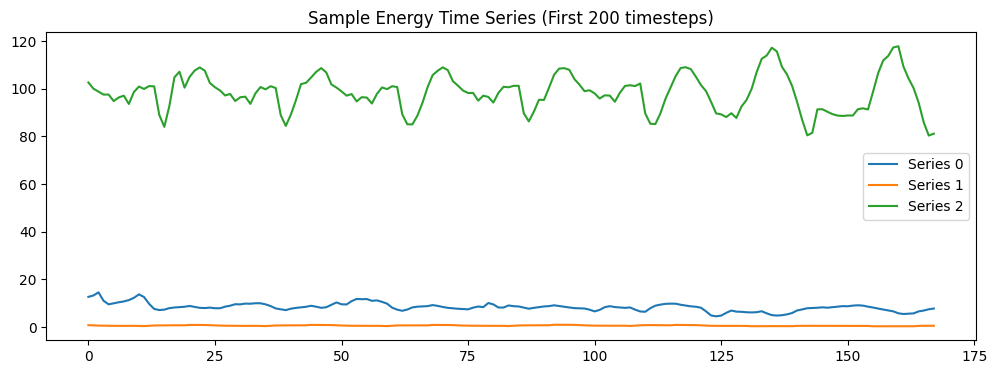

In [5]:
# Plot a few sample time series
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
for i in range(min(3, num_series)):
    plt.plot(X_raw[i, :200], label=f"Series {i}")
plt.title("Sample Energy Time Series (First 200 timesteps)")
plt.legend()
plt.show()

### Choose a Appliance for Classification

In [6]:
label_name = "heat_rejection_ON"

In [7]:
def prepare_label_data(X_processed, labels_df, label_name):
    if label_name not in labels_df.columns:
        return None

    y_raw = labels_df[label_name].values
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y_raw)

    if len(np.unique(y_encoded)) <= 1:
        return None

    X_train, X_val, y_train, y_val = train_test_split(
        X_processed,
        y_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_encoded
    )

    return X_train, X_val, y_train, y_val, len(np.unique(y_encoded))

INFO:p-136378:t-131051249092416:category.py:update:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:p-136378:t-131051249092416:category.py:update:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


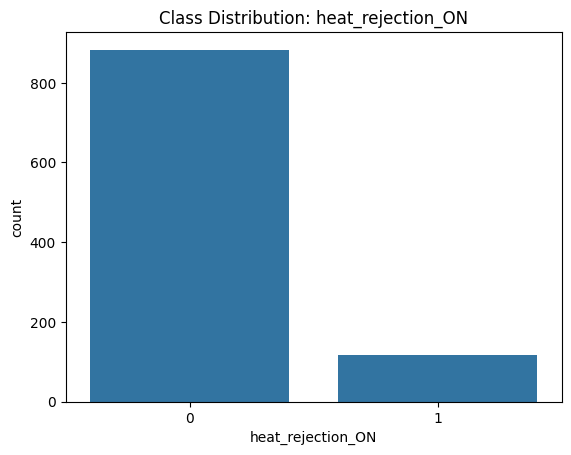

heat_rejection_ON
0    0.883
1    0.117
Name: proportion, dtype: float64


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=labels_df[label_name])
plt.title(f"Class Distribution: {label_name}")
plt.show()

print(labels_df[label_name].value_counts(normalize=True))


In [9]:

# ===============================
# --- Preprocessing ---
# ===============================

# Define fixed context length
context_length = 512

# Initialize processed array
X_processed = np.zeros((num_series, context_length))

for i in tqdm(range(num_series), desc="Processing Series"):
    
    # Extract single series
    series = X_raw[i, :]
    
    # Replace NaN values with 0
    series = np.nan_to_num(series, nan=0.0)
    
    # Truncate or pad to fixed context length
    if len(series) > context_length:
        X_processed[i, :] = series[:context_length]
    else:
        X_processed[i, :len(series)] = series

# Add channel dimension
X_processed = X_processed[:, :, np.newaxis]

print("Final processed shape:", X_processed.shape)



Processing Series:   0%|          | 0/1000 [00:00<?, ?it/s]

Final processed shape: (1000, 512, 1)


In [10]:

X_train, X_val, y_train, y_val, num_labels = prepare_label_data(X_processed, labels_df, label_name)

### Dummy Classifier

In [11]:
# Flatten for sklearn (remove channel dim)
X_train_flat = X_train.squeeze(-1).reshape(X_train.shape[0], -1)
X_val_flat   = X_val.squeeze(-1).reshape(X_val.shape[0], -1)

# Initialize Dummy
dummy = DummyClassifier(strategy="most_frequent")

# Train on train set
dummy.fit(X_train_flat, y_train)

# Predict on validation set
y_pred_dummy = dummy.predict(X_val_flat)

# Metrics
acc_dummy = accuracy_score(y_val, y_pred_dummy)
f1_dummy  = f1_score(y_val, y_pred_dummy, average="macro", zero_division=0)

print("Dummy Classifier Results")
print("Accuracy:", acc_dummy)
print("Macro F1:", f1_dummy)

Dummy Classifier Results
Accuracy: 0.885
Macro F1: 0.46949602122015915


## Loading EnergyTSPulse

In [12]:
from tsfm_public.models.tspulse import TSPulseForClassification


# Select device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



model = TSPulseForClassification.from_pretrained(
    "sriv-naman-iisc/Energy-FM-v1",
    revision="energy-tspulse",
    num_targets=2,   ## No. of classes
).to(device)

INFO:p-136378:t-131051249092416:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
INFO:p-136378:t-131051249092416:modeling_tspulse.py:_init_weights:Initializing Linear layers with method: pytorch
Some weights of TSPulseForClassification were not initialized from the model checkpoint at sriv-naman-iisc/Energy-FM-v1 and are newly initialized: ['decoder_with_head.head.head_norm.norm.bias', 'decoder_with_head.head.head_norm.norm.weight', 'decoder_with_head.head.loc_scale_norm.bias', 'decoder_with_head.head.loc_scale_norm.weight', 'decoder_with_head.head.projection.bias', 'decoder_with_head.head.projection.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Custom Torch Dataset for EnergyTSpulse for Classification

In [13]:
class ClassificationDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return { "past_values": self.X[idx], "target_values": self.y[idx] }



In [14]:
def create_dataloaders(X_train, X_val, y_train, y_val, batch_size=32):

    train_dataset = ClassificationDataset(X_train, y_train)
    val_dataset   = ClassificationDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader


#### Create Data Loaders for training and validation

In [15]:

train_loader, val_loader = create_dataloaders(
    X_train, X_val, y_train, y_val
)

In [16]:
def compute_class_weights(y_train, num_labels, device):
    y_flat = y_train.ravel()
    class_counts = np.bincount(y_flat, minlength=num_labels)

    weights = len(y_flat) / (num_labels * (class_counts + 1e-6))
    weights = torch.tensor(weights, dtype=torch.float, device=device)

    return weights


In [17]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import torch
from tqdm import tqdm


def evaluate_model(model, dataloader, device):
    """
    Evaluate classification model on validation/test set.

    Returns:
        dict with accuracy and macro F1 score.
    """

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):

            inputs = {k: v.to(device) for k, v in batch.items() if k != "target_values"}
            labels = batch["target_values"].to(device).view(-1)

            # Create observed mask
            inputs["past_observed_mask"] = (inputs["past_values"] != 0.0)

            outputs = model(**inputs)
            logits = outputs.prediction_outputs

            # If temporal dimension exists → average
            if logits.dim() > 2:
                logits = logits.mean(dim=1)

            preds = torch.argmax(logits, dim=-1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    # Convert to numpy
    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro
    }

### Finetuning EnergyTSPulse for Classification

In [18]:
from sklearn.metrics import accuracy_score, f1_score
import torch
from tqdm import tqdm


def train_model(
    model,
    train_loader,
    val_loader,
    y_train,
    num_labels,
    device,
    epochs=50,
    lr=1e-5,
):

    # --------------------
    # Compute class weights
    # --------------------
    class_weights = compute_class_weights(y_train, num_labels, device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)

    for epoch in range(1, epochs + 1):

        # --------------------
        # Training
        # --------------------
        model.train()
        total_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch}"):

            inputs = {k: v.to(device) for k, v in batch.items() if k != "target_values"}
            labels = batch["target_values"].to(device).view(-1)

            inputs["past_observed_mask"] = (inputs["past_values"] != 0.0)

            optimizer.zero_grad()

            outputs = model(**inputs)
            logits = outputs.prediction_outputs

            if logits.dim() > 2:
                logits = logits.mean(dim=1)

            loss = loss_fct(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        # --------------------
        # Validation
        # --------------------
        eval_results = evaluate_model(model, val_loader, device)

        print(
            f"Epoch {epoch:02d} | "
            f"Loss: {avg_loss:.4f} | "
            f"Val Acc: {eval_results['accuracy']:.4f} | "
            f"Val F1: {eval_results['f1_macro']:.4f}"
        )

    return model

In [19]:
model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    y_train=y_train,
    num_labels=num_labels,
    device=device,
    epochs=20,        
    lr=1e-5
)

Epoch 1: 100%|██████████| 25/25 [00:00<00:00, 33.75it/s]


Epoch 01 | Loss: 0.6911 | Val Acc: 0.7650 | Val F1: 0.5454


Epoch 2: 100%|██████████| 25/25 [00:00<00:00, 55.54it/s]


Epoch 02 | Loss: 0.7041 | Val Acc: 0.7900 | Val F1: 0.5504


Epoch 3: 100%|██████████| 25/25 [00:00<00:00, 61.85it/s]


...

Epoch 18 | Loss: 0.6952 | Val Acc: 0.7450 | Val F1: 0.5978


Epoch 19: 100%|██████████| 25/25 [00:00<00:00, 52.72it/s]


Epoch 19 | Loss: 0.6915 | Val Acc: 0.7050 | Val F1: 0.5667


Epoch 20: 100%|██████████| 25/25 [00:00<00:00, 61.35it/s]
                                                 

Epoch 20 | Loss: 0.6881 | Val Acc: 0.6200 | Val F1: 0.5123


### Inferencing Finetuned EnergyTSPulse for Classification

In [20]:
import torch
import numpy as np
from tqdm import tqdm

def get_predictions(model, dataloader, device):
    """
    Runs inference and returns predicted labels and true labels.
    """
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):

            # Move tensors to device
            inputs = {k: v.to(device) for k, v in batch.items() if k != "target_values"}
            labels = batch["target_values"].to(device)

            # Observed mask
            inputs["past_observed_mask"] = (inputs["past_values"] != 0.0)

            # Forward pass
            outputs = model(**inputs)
            logits = outputs.prediction_outputs

            # If temporal dimension exists → average
            if logits.dim() > 2:
                logits = logits.mean(dim=1)

            labels = labels.view(-1)

            preds = torch.argmax(logits, dim=-1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()


In [21]:
# Get predictions
y_pred, y_true = get_predictions(model, val_loader, device)



accuracy = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

print(f"Validation Accuracy : {accuracy:.4f}")
print(f"Validation Macro F1 : {f1_macro:.4f}")

print(classification_report(y_true, y_pred, zero_division=0))

Evaluating: 100%|██████████| 7/7 [00:00<00:00, 79.48it/s]

Validation Accuracy : 0.6200
Validation Macro F1 : 0.5123
              precision    recall  f1-score   support

           0       0.93      0.62      0.74       177
           1       0.18      0.65      0.28        23

    accuracy                           0.62       200
   macro avg       0.56      0.63      0.51       200
weighted avg       0.85      0.62      0.69       200

